# 06 · The business decision engine

A model outputs probabilities, but a bank ultimately needs a decision. Different mistakes have different costs:

- A missed fraud (false negative) ≈ 200 units.
- A blocked legitimate transaction (false positive) ≈ 5 units.

Because these costs are highly asymmetric, the default 0.5 threshold is rarely optimal. In this notebook, we evaluate different thresholds, compute the total business cost of each, and identify the operating point that minimizes expected loss.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import fraud_utils as fu

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid")
ART = fu.ARTIFACTS_DIR
RNG = np.random.default_rng(42)

In [2]:
scores = pd.read_parquet(os.path.join(ART, '03_scores.parquet'))
metrics = pd.read_parquet(os.path.join(ART, '04_metrics.parquet'))
y = scores['y_true'].values

best_model = metrics['auc_pr'].idxmax()
y_score = scores[best_model].values
print('optimising thresholds for the best model:', best_model)
print('cost of a missed fraud :', fu.COST_FALSE_NEGATIVE)
print('cost of a false alarm  :', fu.COST_FALSE_POSITIVE)

optimising thresholds for the best model: xgboost
cost of a missed fraud : 200.0
cost of a false alarm  : 5.0


## Sweep the threshold

`sweep_thresholds` evaluates business cost across thresholds from 0.01 to 0.99. For each threshold it records precision, recall, confusion-matrix counts and total cost. The threshold with the lowest cost becomes the recommended operating point.

In [3]:
sweep = fu.sweep_thresholds(y, y_score)
best_row = sweep.loc[sweep['cost'].idxmin()]
default_row = sweep.iloc[(sweep['threshold'] - 0.5).abs().argmin()]
print('default 0.5 cost :', f"{default_row['cost']:,.0f}")
print('optimal threshold:', f"{best_row['threshold']:.2f}",
      '| cost:', f"{best_row['cost']:,.0f}")
sweep.head()

default 0.5 cost : 4,660
optimal threshold: 0.08 | cost: 3,705


,threshold,tp,fp,fn,tn,precision,recall,cost
0,0.0100,105,94,18,70985,0.5276,0.8537,"4,070.0000"
1,0.0200,105,56,18,71023,0.6522,0.8537,"3,880.0000"
2,0.0300,105,40,18,71039,0.7241,0.8537,"3,800.0000"
3,0.0400,105,31,18,71048,0.7721,0.8537,"3,755.0000"
4,0.0500,105,27,18,71052,0.7955,0.8537,"3,735.0000"


**Observation:** The default threshold of 0.5 is not cost-optimal. Lowering the threshold to 0.08 reduces total cost from 4,660 to 3,705 units by catching more fraud, even at the expense of additional false positives.

## The cost curve

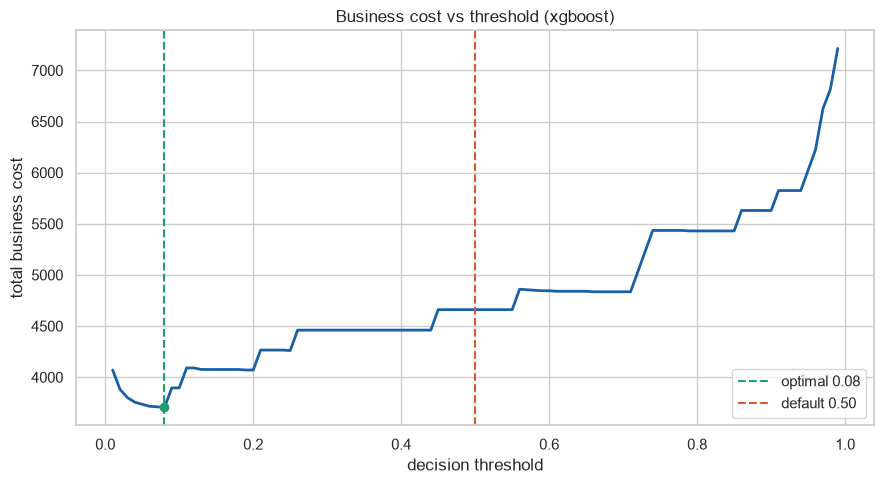

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sweep['threshold'], sweep['cost'], color='#185FA5', lw=2)
ax.axvline(best_row['threshold'], color='#1D9E75', ls='--',
           label=f"optimal {best_row['threshold']:.2f}")
ax.axvline(0.5, color='#D85A30', ls='--', label='default 0.50')
ax.scatter([best_row['threshold']], [best_row['cost']], color='#1D9E75', zorder=5)
ax.set_xlabel('decision threshold'); ax.set_ylabel('total business cost')
ax.set_title(f'Business cost vs threshold ({best_model})')
ax.legend(); plt.tight_layout(); plt.show()

### Observation

The minimum-cost operating point occurs at a threshold of 0.08, not the default 0.50. Lowering the threshold catches more fraud and reduces overall business cost, despite increasing false positives.

## Precision and recall at the chosen threshold

Lowering the threshold catches more fraud (higher recall) at the price of more false alarms (lower precision). The cost-optimal point picks that trade-off *for you*, using the actual cost numbers instead of a gut feel.

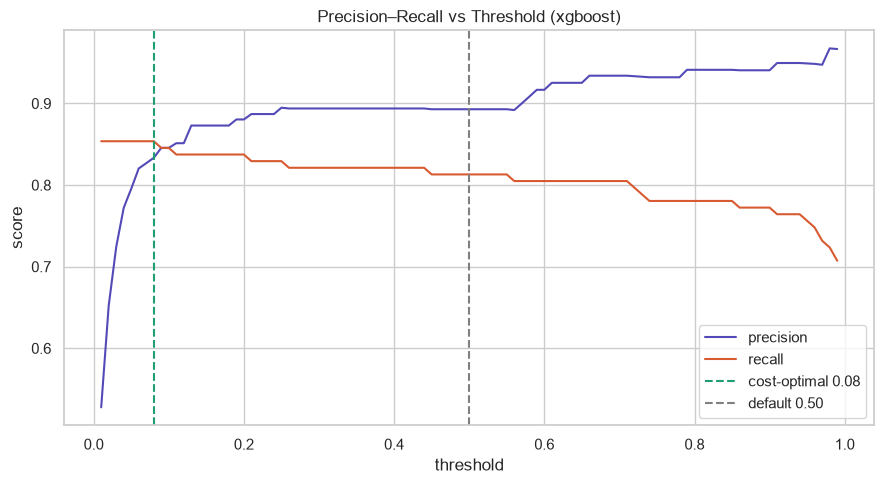

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sweep['threshold'], sweep['precision'], label='precision', color='#534AB7')
ax.plot(sweep['threshold'], sweep['recall'], label='recall', color='#D85A30')
ax.axvline(best_row['threshold'], color='#1D9E75', ls='--',
           label=f"cost-optimal {best_row['threshold']:.2f}")
ax.axvline(0.5, color='gray', ls='--',
           label='default 0.50')
ax.set_xlabel('threshold'); ax.set_ylabel('score'); ax.legend()
ax.set_title(f'Precision–Recall vs Threshold ({best_model})')
plt.tight_layout(); plt.show()

### Observation

The cost-optimal threshold (0.08) balances precision and recall. A lower threshold catches more fraud, while a higher threshold reduces false alarms but allows more fraudulent transactions to pass through.

## Per-10,000-transaction savings & the final recommendation

In [8]:
n_test = len(y)
per_10k = 10_000 / n_test
saving_total = default_row['cost'] - best_row['cost']
saving_10k = saving_total * per_10k

print(f'Test set: {n_test:,} transactions')
print(f'Cost at default 0.50 : {default_row["cost"]:,.0f}')
print(f'Cost at optimal {best_row["threshold"]:.2f} : {best_row["cost"]:,.0f}')
print(f'Saving over the test set: {saving_total:,.0f}')
print(f'Saving per 10,000 transactions: {saving_10k:,.0f}')

Test set: 71,202 transactions
Cost at default 0.50 : 4,660
Cost at optimal 0.08 : 3,705
Saving over the test set: 955
Saving per 10,000 transactions: 134


In [12]:
recommendation = (
    f"Recommendation: deploy '{best_model}' with a threshold of "
    f"{best_row['threshold']:.2f}. This setting captures "
    f"{best_row['recall']:.0%} of fraud cases at "
    f"{best_row['precision']:.0%} precision and reduces the expected "
    f"cost by about {saving_10k:,.0f} units per 10,000 transactions "
    f"compared with the default threshold of 0.50."
)
print(recommendation)

Recommendation: deploy 'xgboost' with a threshold of 0.08. This setting captures 85% of fraud cases at 83% precision and reduces the expected cost by about 134 units per 10,000 transactions compared with the default threshold of 0.50.


### Observation

The default threshold of 0.50 is not the best choice for this fraud-detection problem. Since missing a fraud is much more expensive than investigating a legitimate transaction, lowering the threshold to 0.08 reduces the overall business cost.

## Takeaways

- A model score becomes a business decision only after choosing a threshold.
- When error costs are unequal, the best threshold is usually not 0.50.
- Threshold selection can have a larger business impact than small differences in model accuracy.

---

## What the whole project shows

1. Accuracy can be misleading for highly imbalanced fraud data; AUC-PR provides a better comparison.
2. On this dataset, XGBoost achieved the strongest overall performance, while the neural network required regularisation to remain competitive.
3. Under temporal drift, all models degraded because future fraud patterns differed from the training data.
4. Retraining was crucial: the neural network recovered quickly once it was exposed to examples of the new fraud pattern.
5. In practice, deployment decisions involve both model selection and threshold selection, guided by business costs.